# mini Shor EXAMPLE-1 with identity padding
dr. kornpob bhirombhakdi 2026-Oct-7

1. this example demonstrates a quantum circuit implementation (qiskit, python3) of Shor's search in RSA encryption.
2. **scene**: an attacker holds a public RSA key `(e, N)`, a ciphertext `C`, and knows the padding protocol (here: identity padding, so the message length `m` in bits is public). The attacker does not know `p`, `q` (where `N = p·q`), and wants the plaintext `M`.
3. **idea**: RSA is only as strong as the difficulty of factoring `N`. Once `N → (p, q)`, everything else is classical: `phi = (p-1)(q-1)`, `d = e^(-1) mod phi`, `M_padded = C^d mod N`, then depad to get `M`.
4. **what is quantum**: only one step, finding the period `r` of `f(x) = a^x mod N`, using phase estimation (`t` counting qubits, `n` work qubits, inverse QFT). Everything else is classical, including continued fractions (measured phase → candidate `r`), the success checks, and the factor extraction `gcd(a^(r/2) ± 1, N)`.
5. **flow**:
```
   pick a (1 < a < N)  ->  [quantum] find r  ->  check r usable  ->  factor N
        -> phi -> d -> C^d mod N -> depad -> M
```
   `r` is usable if `a^r ≡ 1 (mod N)`, `r` is even, and `a^(r/2) ≢ ±1 (mod N)`. Otherwise try another measurement outcome, then another `a`.

6. **two roles, kept separate**
   - *sender / test harness* (`RSA_identityPadding_encrypt`): knows `M_bits, p, q, e`; produces the public package `(e, N, C, padding)`.
   - *attacker* (`attack`): sees only that public package; do not see `p, q` which only appear in the harness. The true `M_bits` is used only in the test loop, to grade the result.
7. **inputs**: each testcase is `(M_bits, p, q, e)`. Requirements: `gcd(e, phi) = 1`, and `M < N`, otherwise decryption returns `M mod N` and the case mismatches by design (e.g. the 9-bit message with `N = 143`).
8. **what the code computes by itself**: `n = N.bit_length()`, `t = 2n`, a shuffled pool of bases `a`, and the modular-multiplication unitary `U|y> = |a·y mod N>` built generically for any `N`. No hand-coded per-`N` circuits.
9. **caveats (please read)**
   - **gcd shortcut**: if a random `a` shares a factor with `N`, the factors fall out classically and no circuit runs. At small `N` this happens often (about 40% of bases for `N = 33`), so a fast "OK" does not prove the quantum step ran. Use `allow_gcd_shortcut=False` to force it.
   - **not a scalable Shor**: the multiplier is a full `2^n × 2^n` permutation matrix, so gate count grows exponentially with `n`. It is fine for `N = 15, 21, 33` in simulation but a test harness, not a scalable construction. Scalable versions use arithmetic circuits (e.g. Beauregard, QFT adders, `O(n^3)` gates) and iterative phase estimation.
   - **hardware**: only `N = 15` is realistic on current noisy devices. Larger `N` needs far deeper circuits than decoherence allows. The classical verification (`p·q = N`, `C^d` re-encrypts to `C`) is noise-proof, so noise can cause a failure but never a wrong answer.
10. **outputs**: for each testcase, the sender package, the recovered bits, the factors `(p, q)`, whether the quantum path was used, and OK/MISMATCH against the true message.

In [4]:
"""
Mini Shor on EXAMPLE-1: 
- scene: there is a ciphertext C, known to be encrypted with RSA public key (e,N) + known customized padding protocol
- EXAMPLE-1: known public key (e,N)=(3,15), ciphertext C=8 + identity padding protocol (implying len(message)=m=3 bits)
- note: in EXAMPLE-1, we will use identity padding.
- quantum step: find the period r of f(x) = a^x mod 15 (phase estimation)
    - a=7 is an arbitrary choice (its period is r=4; 7^(i) mod 15 = 7^(i+4) mod 15 for any valid i
    - any a with 1 < a < N and gcd(a,N)=1 is a valid input; some valid a may not be useful (e.g. a=14 in this EXAMPLE; see following check success), pick different a.
    - success: r is even and a^(r/2) ≢ -1 (mod N)
      <-> a^(r/2) mod N != N-1 <-> N does not divide a^(r/2)+1
      then the factors are gcd(a^(r/2) ± 1, N)
    - failure: r is odd, or a^(r/2) ≡ -1 (mod N) -> pick another a (e.g. a=14 fails here)
    - a single measurement can give an unusable r, so the run is repeated.
- FLOW:
    pick valid a: 1 < a < N, gcd(a,N)=1   (classical; if gcd>1 it is already a factor)
    -> find r                             (quantum: phase estimation; classical: continued fractions)
    -> check success                      (classical: decide whether a candidate r can be used to FACTOR N)
        checks: a^r ≡ 1 (mod N), r even, a^(r/2) ≢ -1 (mod N)
        else try another measurement outcome, then another a
    -> FACTOR: (p,q) = gcd(a^(r/2) ± 1, N)   (classical; verify p·q = N)
    -> phi = (p-1)(q-1)                   (classical)
    -> d = e^(-1) mod phi                 (classical)
    -> M_padded = C^d mod N               (classical)
    -> known depadding protocol -> M      (classical)
"""
import random
import numpy as np
from math import gcd
from fractions import Fraction
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator

def c_mult_mod(a, power, N, n):
    """controlled-U^power, U|y> = |a*y mod N>; y >= N left untouched"""
    k = pow(a, power, N)                       # needs gcd(a,N)=1 so U is a permutation
    U = np.zeros((2**n, 2**n))
    for y in range(2**n):
        U[(k * y) % N if y < N else y, y] = 1
    return UnitaryGate(U, label=f"{a}^{power} mod {N}").control()

def period_finding_circuit(a, N, n, t):
    cnt  = QuantumRegister(t, "count")
    work = QuantumRegister(n, "work")
    res  = ClassicalRegister(t, "phase")
    qc = QuantumCircuit(cnt, work, res)
    qc.h(cnt)
    qc.x(work[0])                              # work = |1>
    for j in range(t):
        qc.append(c_mult_mod(a, 2**j, N, n), [cnt[j]] + list(work))
    qc.append(QFTGate(t).inverse(), cnt)
    qc.measure(cnt, res)
    return qc

def run_phase_estimation(a, N, n, t, shots=1024):
    qc = period_finding_circuit(a, N, n, t)
    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
    return counts, qc

def candidate_period(bits, t, N):
    return Fraction(int(bits, 2) / 2**t).limit_denominator(N).denominator

def check_success(a, r, N):
    if pow(a, r, N) != 1:          return False, "a^r != 1"
    if r % 2:                      return False, "r is odd"
    if pow(a, r // 2, N) == N - 1: return False, "a^(r/2) = -1 (mod N)"
    return True, "ok"

def factor(a, r, N):
    x = pow(a, r // 2, N)
    p, q = gcd(x - 1, N), gcd(x + 1, N)
    assert 1 < p < N and 1 < q < N and p * q == N
    return tuple(sorted((p, q)))

def RSA_identityPadding_encrypt(M_bits, p, q, e):
    N, m = p * q, len(M_bits)
    M_int = int(M_bits, 2)
    if gcd(e, (p - 1) * (q - 1)) != 1:
        return "SKIP", "e not invertible mod phi"
    M_padded = M_int # identity padding
    C = pow(M_padded, e, N) # RSA encrypt                           
    padding = {"m": m, "protocol": "identity"}
    sender_package = (e,N,C,padding)
    return sender_package

# ---- attacker's knowledge of padding protocols (public) ----
def depad_identity(x, m):
    return format(x, f"0{m}b")

DEPAD = {"identity": depad_identity}      # add other protocols here later

def attack(e, N, C, padding, shots=1024):
    if padding["protocol"] not in DEPAD:
        return None, f"unknown padding protocol {padding['protocol']}", None
    n, t = N.bit_length(), 2 * N.bit_length()
    bases = list(range(2, N - 1)); random.shuffle(bases)
    qc = None                                  # NEW: defined on every path
    for a in bases:
        g = gcd(a, N)
        if g > 1:
            p, q = sorted((g, N // g))
            qc = None                          # NEW: shortcut, no circuit produced the factors
            break
        counts, qc = run_phase_estimation(a, N, n, t, shots)
        for bits in sorted(counts, key=counts.get, reverse=True):
            r = candidate_period(bits, t, N)
            ok, _ = check_success(a, r, N)
            if ok:
                p, q = factor(a, r, N); break
        else:
            continue
        break
    else:
        return None, "no usable base", qc      # CHANGED: 3 values
    phi = (p - 1) * (q - 1)
    d = pow(e, -1, phi)
    M_padded = pow(C, d, N)
    return DEPAD[padding["protocol"]](M_padded, padding["m"]), (p, q), qc

In [5]:
from datetime import datetime, timezone

testcases = [("010",3,5,3), 
             # ("101",3,5,3), 
             ("011",3,7,5), # ~5s
             # ("011",3,11,3), # ~20s
             ("011010",3,11,3), # ~24s    
             # ("011",11,13,7), # local aer simulation failed here
             # ("01101",11,13,7), 
             # ("011011",11,13,7),
             # ("0110101",11,13,7), 
             # ("01100101",11,13,7), 
             # ("011001011",11,13,7),
            ]

#########################
#########################
# ---- test loop: the only place the true message is used ----
for M_bits, p, q, e in testcases:
    pkg = RSA_identityPadding_encrypt(M_bits, p, q, e)
    if pkg[0] == "SKIP":
        print((M_bits, p, q, e), "-> SKIP:", pkg[1]); continue
    local_now = datetime.now()
    got, info, qc = attack(*pkg)                  # attack sees only (e, N, C, padding)
    local_done = datetime.now()
    print((M_bits, p, q, e), "->", pkg, "->", got, info, "| OK" if got == M_bits else "| MISMATCH")
    print(f"time-use: {(local_done - local_now).total_seconds():.3f} seconds")

('010', 3, 5, 3) -> (3, 15, 8, {'m': 3, 'protocol': 'identity'}) -> 010 (3, 5) | OK
time-use: 0.000 seconds
('011', 3, 7, 5) -> (5, 21, 12, {'m': 3, 'protocol': 'identity'}) -> 011 (3, 7) | OK
time-use: 5.229 seconds
('011010', 3, 11, 3) -> (3, 33, 20, {'m': 6, 'protocol': 'identity'}) -> 011010 (3, 11) | OK
time-use: 21.246 seconds


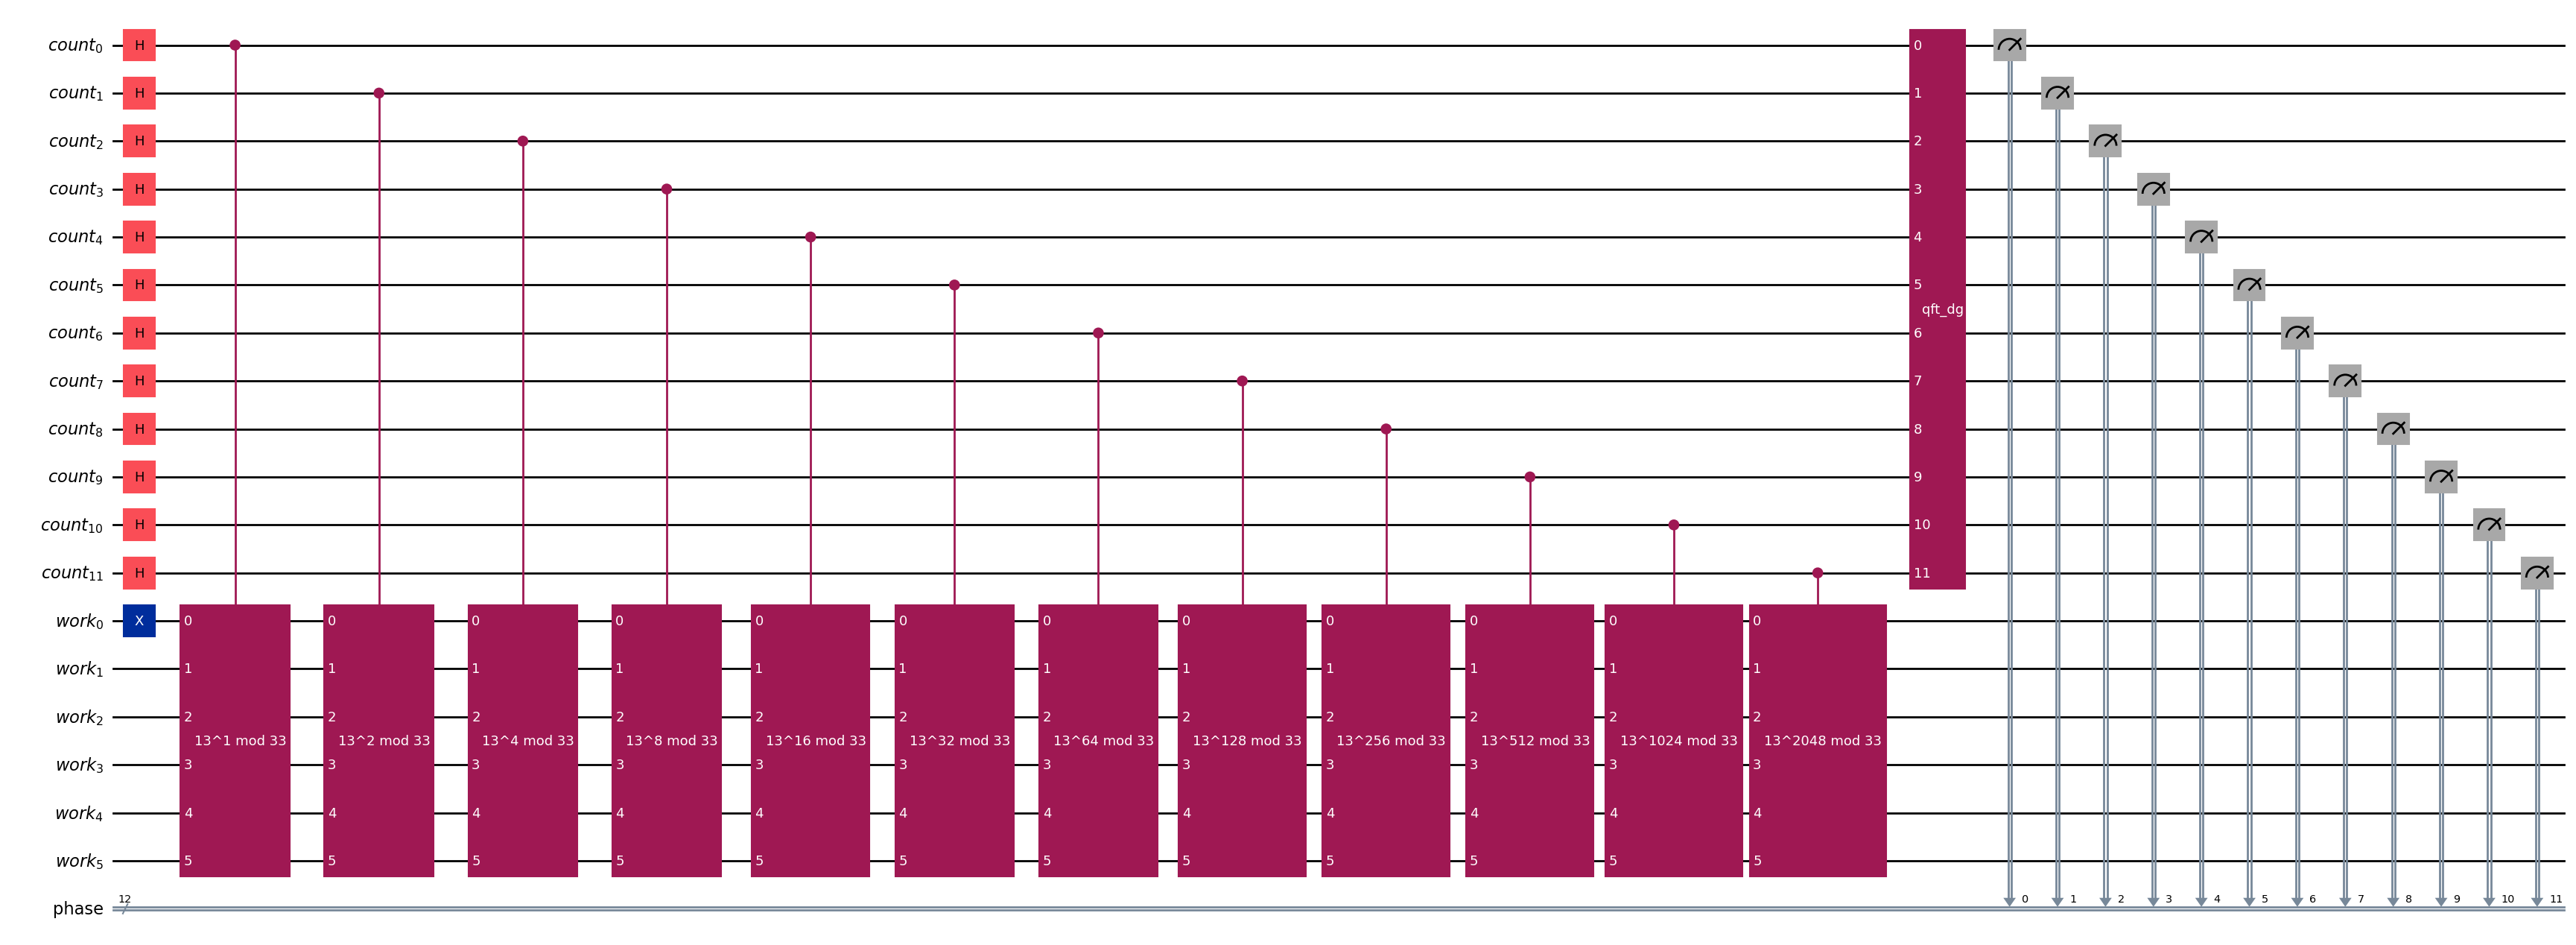

In [6]:
qc.draw('mpl', fold=-1, filename='miniShor-example-1.png')

## Theory/Code Explained

### 1. Why factoring `N` breaks RSA
- Encryption: `C = M_padded^e mod N`. Decryption needs `d = e^(-1) mod phi`, where `phi = (p-1)(q-1)`.
- `phi` is easy to compute once `N = p·q` is factored. Without the factors, no efficient classical method is known.
- Once `d` is known, `C^d = M^(ed) ≡ M (mod N)` by Euler's theorem, since `ed ≡ 1 (mod phi)`. This requires `M < N`, otherwise only `M mod N` is recovered.
- Code: `RSA_identityPadding_encrypt` (sender side), and the last lines of `attack` (`phi`, `d`, `pow(C, d, N)`, depad).

### 2. From factoring to period finding (classical reduction)
- Pick `a` with `1 < a < N`. If `gcd(a, N) > 1`, a factor falls out immediately (the "gcd shortcut"; no quantum step).
- Otherwise `a` has a multiplicative order `r`: the smallest `r > 0` with `a^r ≡ 1 (mod N)`.
- If `r` is even, then `(a^(r/2) - 1)(a^(r/2) + 1) ≡ 0 (mod N)`.
- Unless `a^(r/2) ≡ ±1 (mod N)`, neither factor is divisible by `N`, so `gcd(a^(r/2) ± 1, N)` are nontrivial factors.
- For `N = p·q`, a random coprime `a` works with probability of at least 1/2, which is why the code retries with another `a`.
- Code: `check_success` (is `r` usable?) and `factor` (the two gcds, then verify `p·q = N`).
- The only hard part is finding `r`. That is the quantum step.

### 3. Quantum step: phase estimation of modular multiplication
- Define the unitary `U|y> = |a·y mod N>`. It is a permutation of basis states, hence unitary, as long as `gcd(a, N) = 1`.
- Its eigenvalues are `e^(2πi·s/r)` for `s = 0..r-1`. The work register starts in `|1>`, which is an equal superposition of all `r` eigenstates.
- Phase estimation therefore returns a measurement `y` with `y/2^t ≈ s/r` for a random `s`.
- Circuit (`period_finding_circuit`):
  1. `H` on the `t` counting qubits creates a superposition of all `x`.
  2. `X` on the work register sets it to `|1>`.
  3. Controlled-`U^(2^j)` from counting qubit `j` kicks the phase back onto the counting register. `c_mult_mod` builds it as the permutation `y -> (a^(2^j) mod N)·y`, with `a^(2^j)` computed classically.
  4. Inverse QFT converts the phase pattern into a peaked distribution.
  5. Measure the counting register.
- Sizes: `n = N.bit_length()` work qubits and `t = 2n` counting qubits. The extra precision lets the classical step recover `r` even when `r` does not divide `2^t`.
- Powers where `a^(2^j) ≡ 1 (mod N)` are skipped, because `U^(2^j)` is then the identity.

### 4. Classical post-processing
- `candidate_period`: continued fractions turn `y/2^t` into the closest fraction `s'/r'` with denominator at most `N`, and `r'` is the candidate period.
- The candidate can be wrong, for example `r' = 1` from `y = 0`, or a divisor of the true `r` when `s` and `r` share a factor.
- `check_success` guards against all of these:
  - `a^r ≡ 1`: is it actually a period?
  - `r` even
  - `a^(r/2) ≢ -1`, and `a^(r/2) ≢ 1` (the trivial roots)
- Outcomes are tried from most to least frequent, then a new `a` is drawn.

### 5. Worked example (`N = 15`, `a = 7`)
- `7^x mod 15` cycles `1, 7, 4, 13, 1, ...`, so `r = 4`.
- With `t = 3`, peaks appear at `y/8 ∈ {0, 1/4, 1/2, 3/4}`, i.e. `y ∈ {000, 010, 100, 110}`.
- `y = 010` gives `1/4`, so `r = 4`. Then `7^2 = 49 ≡ 4`, and `gcd(3, 15) = 3`, `gcd(5, 15) = 5`. The factors are `(3, 5)`.
- `y = 000` gives `r = 1`, which `check_success` rejects.
- Since `a = 14 ≡ -1`, its order is 2 and `a^(r/2) = 14 ≡ -1 (mod 15)`. That is the standard failure case. Try it by hand.

### 6. Trust model of the code
- `attack` sees only `(e, N, C, padding)`. The true message is used only in the test loop to grade the output.
- Noise or a bad measurement can only cause a failed run, never a wrong answer. A successful run's output is checked classically (`p·q = N`, and re-encrypting `M_padded` returns `C`).
- Padding is a plug-in: `DEPAD[protocol]` holds the attacker's public knowledge of each scheme. Identity padding is the simplest one.

### 7. Scope and limits
- `c_mult_mod` builds a full `2^n × 2^n` matrix, so cost grows exponentially with `n`. This explains the jump from about 1 s (`N = 21`) to about 20 s (`N = 33`), and the failure at `N = 143`.
- Scalable constructions use arithmetic circuits (QFT-based modular adders, Beauregard 2003) with polynomial gate counts, plus iterative phase estimation to cut qubits.
- Only `N = 15` is realistic on today's noisy hardware. Small-`N` demos like this one also benefit from structure that does not exist at RSA sizes (see Smolin, Smith and Vargo 2013). Treat this notebook as a teaching demonstration, not a scalable attack.
- Real RSA sizes need error-corrected logical qubits (Gidney and Ekerå 2019; Gidney 2025 for updated estimates).

### References
- Shor, P. W. (1994). Algorithms for quantum computation: discrete logarithms and factoring.
- Beauregard, S. (2003). Circuit for Shor's algorithm using 2n+3 qubits.
- Smolin, Smith, Vargo (2013). Oversimplifying quantum factoring. Nature 499.
- Gidney, C. and Ekerå, M. (2021). How to factor 2048 bit RSA integers in 8 hours using 20 million noisy qubits. Quantum 5, 433 (arXiv 2019).

## Quantum Phase Estimation

Short answer: yes. **Phase kickback** moves the phase of `U` onto the counting register, and the **inverse QFT** reads that phase out as a bitstring.

### 1. Eigenstates of `U`
`U|y> = |a·y mod N>`, with `a^r ≡ 1 (mod N)` and `0 <= y < N`. Note that

- Unitary Guarantee: Because $\gcd(a, N) = 1$, multiplication by $a \pmod N$ is a 1-to-1 bijection (permutation) over $\{0, 1, \dots, N-1\}$. Thus, $U$ is unitary ($U^\dagger U = I$).

Starting from `|1>`, `U` cycles through the orbit `|1=a^0>, |a>, |a²>, ..., |a^(r-1)>` and returns. Define, for `s = 0..r-1`:

$$|u_s\rangle = \frac{1}{\sqrt r}\sum_{k=0}^{r-1} e^{-2\pi i sk/r}\,|a^k \bmod N\rangle$$

Apply `U` and shift `k → k+1`. The wraparound `a^r = 1` makes the shift cyclic:

$$U|u_s\rangle = \frac{1}{\sqrt r}\sum_{k} e^{-2\pi i sk/r}|a^{k+1}\rangle = e^{2\pi i s/r}\,|u_s\rangle$$

So the eigenvalues are `e^{2πi φ_s}` with `φ_s = s/r`. Note that `r` is hidden in the phase.

### 2. `|1>` is an equal superposition of the eigenstates

$$\frac{1}{\sqrt r}\sum_{s=0}^{r-1}|u_s\rangle = \frac{1}{r}\sum_{k}\Big(\sum_{s} e^{-2\pi i sk/r}\Big)|a^k\rangle = |a^0\rangle = |1\rangle$$

This uses `Σ_s e^{-2πi sk/r} = r·δ_{k,0}`. We can't prepare `|u_s>` directly because it needs `r`, but `|1>` is easy to prepare, and it contains every `|u_s>` with weight `1/r`.

### 3. Phase kickback
Take one control qubit in `|+>`, apply controlled-`U^(2^j)` to `|u_s>`, and use `U^(2^j)|u_s> = e^{2πi 2^j φ}|u_s>`:

$$\frac{|0\rangle+|1\rangle}{\sqrt2}\otimes|u_s\rangle \;\to\; \frac{|0\rangle + e^{2\pi i\,2^j\varphi}|1\rangle}{\sqrt2}\otimes|u_s\rangle$$

The eigenstate is unchanged and the eigenvalue becomes a relative phase on the control. That is the kickback.

Do this for all `t` counting qubits `j = 0..t-1` (this is the controlled-`U^(2^j)` loop in the code). Because `x = Σ_j x_j 2^j`:

$$\bigotimes_{j}\frac{|0\rangle+e^{2\pi i\,2^j\varphi}|1\rangle}{\sqrt2} = \frac{1}{\sqrt{2^t}}\sum_{x=0}^{2^t-1} e^{2\pi i\,\varphi x}\,|x\rangle$$

The counting register now holds a phase ramp in `x` with slope `φ = s/r`.

### 4. Inverse QFT reads out the slope
`QFT†|x> = 2^{-t/2} Σ_y e^{-2πi xy/2^t}|y>`, so the amplitude of `|y>` is

$$\alpha_y = \frac{1}{2^t}\sum_{x=0}^{2^t-1} e^{2\pi i\,x(\varphi - y/2^t)}$$

- If `φ = y/2^t` exactly, then `α_y = 1`. The register is the bitstring `y` with certainty.
- Otherwise `α_y` is a geometric sum peaked at `y ≈ 2^t φ`. The nearest `y` has `|α_y|² ≥ 4/π² ≈ 0.41`.

### 5. Putting it together
The full state is `(1/√r) Σ_s |ψ_s>|u_s>`, where `|ψ_s>` is the counting register after `QFT†`, peaked at `y ≈ 2^t s/r`. Measuring the counting register picks `s` uniformly from `0..r-1`:

$$P(y) = \frac{1}{r}\sum_{s=0}^{r-1}|\alpha_y(s/r)|^2, \qquad \frac{y}{2^t}\approx\frac{s}{r}\ \ (s \text{ uniform})$$

### 6. Recovering `r` (classical)
If `|y/2^t − s/r| ≤ 1/2^{t+1} < 1/(2N²)`, then `s/r` is a convergent of the continued fraction of `y/2^t`. With `r < N < 2^n` and `t = 2n`, this holds. That is why the code uses `t = 2n` and `Fraction(...).limit_denominator(N)`.

Failure modes, all caught by `check_success`:
- `s = 0` gives `y = 0` and `r' = 1` (useless).
- `gcd(s, r) > 1` gives `s/r` in lowest terms with denominator `r' | r`, a divisor of the true `r`.

### 7. Check with `N = 15, a = 7`
The order is `r = 4`, so `φ ∈ {0, 1/4, 1/2, 3/4}`. With `t = 3`, `y = 8φ ∈ {0, 2, 4, 6}`, which is `{000, 010, 100, 110}`. All phases are exact multiples of `1/8`, so `α_y = 1` and the peaks are sharp. Each `s` appears with probability `1/4`.

### What Shor can easily break?

**Rule of thumb:** Shor breaks any scheme whose security rests on a *hidden period in an abelian group*. Factoring and discrete logarithms are both instances of this (the abelian hidden subgroup problem), and the quantum period-finding step from this notebook solves them in polynomial time.

#### 1. Same engine, different `f(x)`

| Problem | Hidden period | Classical best | Shor |
|---|---|---|---|
| Factoring `N = p·q` | `r` in `f(x) = a^x mod N` | sub-exponential (GNFS) | `O(n^3)` gates, `n = log N` |
| Discrete log in `Z_p*`: given `g, h = g^k` find `k` | `(a,b)` with `g^a h^b` constant, which gives `a + kb ≡ 0` | sub-exponential | polynomial |
| Elliptic-curve discrete log: given `P, Q = kP` find `k` | same, with `f(a,b) = aP + bQ` | fully exponential `O(√n_group)` | polynomial |

Only `U` and the function being evaluated change. The rest is the same phase kickback, inverse QFT, and continued fractions as in the code.

#### 2. What falls

- **RSA** (encryption and signatures): factor `N`, then `d = e^(-1) mod phi`. Key size only changes the cost polynomially.
- **Diffie-Hellman, DSA, ElGamal**: discrete log in `Z_p*`.
- **ECDH, ECDSA, EdDSA, Ed25519, secp256k1** (TLS, SSH, Signal, Bitcoin/Ethereum signatures): elliptic-curve discrete log.
- **ECC is the easier target.** A 256-bit curve has about the same classical security as RSA-3072, but the group is much smaller to simulate. Resource estimates need fewer logical qubits and gates for ECC-256 than for RSA-2048.

#### 3. Padding does not help
OAEP, PKCS#1 and the `identity` padding in this notebook only guard against *structural* attacks on the ciphertext. Once `p, q` are known, the attacker holds `d`, and depadding is a public, deterministic step. This is why `attack` treats padding as a plug-in that comes last.

#### 4. What Shor does *not* break

| Primitive | Best known quantum attack | Effect |
|---|---|---|
| Symmetric ciphers (AES) | Grover: `2^k → 2^(k/2)` | AES-128 is weakened, AES-256 is fine |
| Hashes (SHA-2/3) | Grover preimage, collisions `2^(n/3)` at best | use 256-bit or larger outputs |
| Lattice (ML-KEM, ML-DSA) | no known Shor-like attack | NIST standards, 2024 |
| Hash-based signatures (SLH-DSA) | only Grover-level | NIST standard, 2024 |
| Code-based (HQC, McEliece) | no known Shor-like attack | HQC selected by NIST in 2025 |

Grover is only a quadratic speedup, and it parallelizes badly. Shor's speedup is superpolynomial, so it is the real threat to public-key cryptography, while symmetric cryptography needs only larger keys.

#### 5. Why it matters before the machine exists
- **Harvest now, decrypt later:** ciphertext recorded today can be decrypted once a large enough quantum computer exists. Long-lived secrets are at risk now.
- **Signatures** only matter if forged before expiry, but long-lived roots of trust and firmware-signing keys must migrate early.
- **Timeline:** Gidney (2025) estimates RSA-2048 with under 1 million noisy qubits in under a week, which is a large drop from 20 million in 2019. No such machine exists today. This notebook's demos reach `N = 15` on hardware, and the gap to useful sizes is large but shrinking.
- **Migration** takes years, so standards bodies are moving now (NIST FIPS 203/204/205, hybrid classical+PQC key exchange in TLS).

#### 6. Caution
"Post-quantum" means *no known* efficient quantum attack, not a proof. The isogeny scheme SIKE was broken in 2022 by a purely **classical** attack, which is why PQC deployments favor hybrid modes and conservative parameters.

#### 7. Takeaway for the notebook
The notebook shows the mechanism at toy scale: the quantum step finds only a period `r`. Everything that turns `r` into a broken cipher (gcd, `phi`, `d`, `C^d mod N`) is classical, cheap and exact. The same recipe, with a different `U`, attacks Diffie-Hellman and elliptic curves.